# MLP Diffusion Model on 2D Shapes — Standalone

Fully self-contained notebook: all classes and functions are defined inline, no imports from the project library.

## Imports

In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Linear
from torch.optim import Adam
from tqdm.auto import trange
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    elif torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')

device = get_device()
print(f'Using device: {device}')

Using device: mps


## Dataset — 2D star shape

In [2]:
def random_radius_function(angles, amplitudes, phases, R0=1):
    freqs = np.arange(1, len(amplitudes) + 1)
    radii = R0 + np.sum(
        amplitudes[None, :] * np.cos(freqs[None, :] * angles[:, None] + phases[None, :]),
        axis=1,
    )
    return radii


def create_random_star_shape(num_points, num_modes):
    amplitudes = 0.4 * np.random.rand(num_modes) - 0.2
    phases = 2 * np.pi * np.random.rand(num_modes)
    angles = np.linspace(0, 2 * np.pi, num_points)
    radii = random_radius_function(angles, amplitudes, phases)
    radius_fun = lambda a: random_radius_function(a, amplitudes, phases)
    x = radii * np.cos(angles)
    y = radii * np.sin(angles)
    pnts = np.vstack((x, y)).T
    return pnts, radius_fun, amplitudes, phases

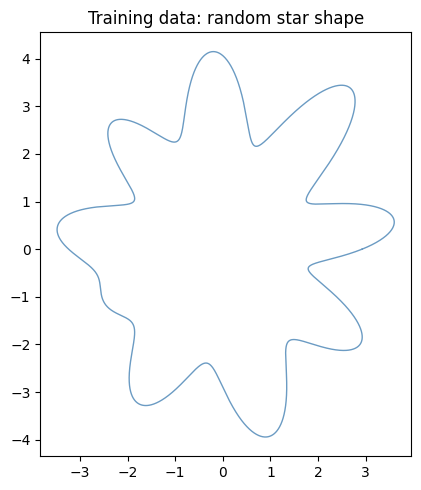

Dataset shape: torch.Size([10000, 2])


In [3]:
torch.manual_seed(0)
np.random.seed(0)

pnts, radius_fun, amplitudes, phases = create_random_star_shape(10000, num_modes=10)
pnts_tsr = 3 * torch.tensor(pnts, dtype=torch.float32)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(pnts_tsr[:, 0], pnts_tsr[:, 1], lw=1, alpha=0.8, color='steelblue')
ax.set_aspect('equal')
ax.set_title('Training data: random star shape')
plt.tight_layout()
plt.show()
print(f'Dataset shape: {pnts_tsr.shape}')

## Model definitions

### `GaussianFourierProjection` — time embedding
Projects a scalar noise level σ into a fixed-frequency sinusoidal feature vector.  
Weights are sampled at init and frozen (not trained).

In [4]:
class GaussianFourierProjection(nn.Module):
    """Random Fourier features for encoding a scalar time/noise level."""
    def __init__(self, embed_dim, scale=1.):
        super().__init__()
        self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)

    def forward(self, t):
        t_proj = t.view(-1, 1) * self.W[None, :] * 2 * math.pi
        return torch.cat([torch.sin(t_proj), torch.cos(t_proj)], dim=-1)

### `UNetMLPBlock` — residual MLP block with adaptive time conditioning
Each block applies LayerNorm → Linear → SiLU, then modulates activations with a  
time-dependent scale+shift (adaptive group norm style), followed by a second Linear  
and a residual skip connection.

In [5]:
class UNetMLPBlock(nn.Module):
    def __init__(self, in_features, out_features, emb_features,
                 dropout=0, skip_scale=1, eps=1e-5, adaptive_scale=True):
        super().__init__()
        self.adaptive_scale = adaptive_scale
        self.dropout = dropout
        self.skip_scale = skip_scale

        self.norm0  = nn.LayerNorm(in_features, eps=eps)
        self.fc0    = Linear(in_features, out_features)
        self.affine = Linear(emb_features, out_features * (2 if adaptive_scale else 1))
        self.norm1  = nn.LayerNorm(out_features, eps=eps)
        self.fc1    = Linear(out_features, out_features)
        self.skip   = None if out_features == in_features else Linear(in_features, out_features)

    def forward(self, x, emb):
        orig = x
        x = self.fc0(F.silu(self.norm0(x)))
        params = self.affine(emb).to(x.dtype)
        if self.adaptive_scale:
            scale, shift = params.chunk(chunks=2, dim=1)
            x = F.silu(torch.addcmul(shift, self.norm1(x), scale + 1))
        else:
            x = F.silu(self.norm1(x.add_(params)))
        x = self.fc1(F.dropout(x, p=self.dropout, training=self.training))
        x = x.add_(self.skip(orig) if self.skip is not None else orig)
        return x * self.skip_scale

### `UNetBlockStyleMLP_backbone` — the score network backbone
A stack of `UNetMLPBlock`s that maps `(x, σ)` → raw network output.  
The EDM preconditioner (below) wraps this to produce the final denoiser.

In [6]:
class UNetBlockStyleMLP_backbone(nn.Module):
    """UNet-style MLP backbone; expects pre-conditioned noise input c_in*x and c_noise = log(σ)/4."""
    def __init__(self, ndim=2, nlayers=5, nhidden=64, time_embed_dim=64):
        super().__init__()
        self.embed = GaussianFourierProjection(time_embed_dim, scale=1)
        layers = nn.ModuleList()
        layers.append(UNetMLPBlock(ndim, nhidden, time_embed_dim))
        for _ in range(nlayers - 2):
            layers.append(UNetMLPBlock(nhidden, nhidden, time_embed_dim))
        layers.append(nn.Linear(nhidden, ndim))
        self.net = layers

    def forward(self, x, t_enc, cond=None):
        # t_enc = log(sigma) / 4  (passed in by EDMPrecondWrapper)
        t_embed = self.embed(t_enc)
        for layer in self.net[:-1]:
            x = layer(x, t_embed)
        return self.net[-1](x)

### `EDMPrecondWrapper` — EDM input/output preconditioning
Implements the Karras et al. 2022 (EDM) preconditioning:  
- `c_skip`, `c_out`, `c_in`, `c_noise` rescale inputs, outputs, and the noise embedding  
- The wrapped backbone only needs to predict the residual; the skip connection handles the trivial part

In [7]:
class EDMPrecondWrapper(nn.Module):
    """EDM preconditioning wrapper (Karras et al. 2022)."""
    def __init__(self, model, sigma_data=0.5, sigma_min=0.002, sigma_max=80, rho=7.0):
        super().__init__()
        self.model      = model
        self.sigma_data = sigma_data
        self.sigma_min  = sigma_min
        self.sigma_max  = sigma_max
        self.rho        = rho

    def forward(self, X, sigma, cond=None):
        sigma[sigma == 0] = self.sigma_min
        sigma_vec = sigma.view([-1] + [1] * (X.ndim - 1))
        c_skip  = self.sigma_data ** 2 / (sigma_vec ** 2 + self.sigma_data ** 2)
        c_out   = sigma_vec * self.sigma_data / (sigma_vec ** 2 + self.sigma_data ** 2).sqrt()
        c_in    = 1 / (self.sigma_data ** 2 + sigma_vec ** 2).sqrt()
        c_noise = sigma.log() / 4
        return c_skip * X + c_out * self.model(c_in * X, c_noise, cond=cond)

### `EDMLoss` — training objective
Samples σ from a log-normal distribution (P_mean, P_std), adds noise to data,  
and computes weighted L2 denoising loss.

In [8]:
class EDMLoss:
    """EDM denoising loss (Karras et al. 2022)."""
    def __init__(self, P_mean=-1.2, P_std=1.2, sigma_data=0.5):
        self.P_mean     = P_mean
        self.P_std      = P_std
        self.sigma_data = sigma_data

    def __call__(self, net, X, labels=None):
        rnd_normal = torch.randn([X.shape[0]] + [1] * (X.ndim - 1), device=X.device)
        sigma  = (rnd_normal * self.P_std + self.P_mean).exp()
        weight = (sigma ** 2 + self.sigma_data ** 2) / (sigma * self.sigma_data) ** 2
        n      = torch.randn_like(X) * sigma
        D_yn   = net(X + n, sigma, cond=labels)
        return weight * (D_yn - X) ** 2

### `train_score_model_custom_loss` — training loop

In [9]:
def train_score_model_custom_loss(
    X_train_tsr, score_model_td, loss_fn,
    lr=0.005, nepochs=750, batch_size=None, device='cpu',
    callback=None, callback_freq=100, callback_step_list=None,
    save_ckpts=False, save_ckpt_step_list=None, ckpt_dir=None,
):
    if callback_step_list is None:
        callback_step_list = []
    if save_ckpt_step_list is None:
        save_ckpt_step_list = []

    def _should_callback(ep):
        if ep == 0 or ep == nepochs - 1:
            return True
        if callback_freq and (ep + 1) % callback_freq == 0:
            return True
        if (ep + 1) in callback_step_list:
            return True
        return False

    score_model_td.to(device)
    X_train_tsr = X_train_tsr.to(device)
    optim = Adam(score_model_td.parameters(), lr=lr)
    pbar  = trange(nepochs)
    score_model_td.train()
    loss_traj = []

    for ep in pbar:
        if batch_size is None:
            loss = loss_fn(score_model_td, X_train_tsr)
        else:
            idx  = torch.randint(0, X_train_tsr.shape[0], (batch_size,))
            loss = loss_fn(score_model_td, X_train_tsr[idx])
        loss = loss.mean()
        optim.zero_grad()
        loss.backward()
        optim.step()
        pbar.set_description(f'step {ep}  loss {loss.item():.3f}')
        if ep == 0:
            print(f'step {ep}  loss {loss.item():.3f}')
        loss_traj.append(loss.item())

        if callback is not None and _should_callback(ep):
            callback(epoch=ep + 1, loss=loss.item(), model=score_model_td)
        if save_ckpts and (ep in save_ckpt_step_list or ep == nepochs - 1 or ep == 0):
            torch.save(score_model_td.state_dict(), f'{ckpt_dir}/model_epoch_{ep:06d}.pth')

    return score_model_td, loss_traj

### `edm_sampler` — probability flow ODE (Heun 2nd-order)
Deterministic sampler from Karras et al. 2022.  
Uses the Euler + 2nd-order Heun correction step.

In [10]:
@torch.no_grad()
def edm_sampler(
    edm, latents, class_labels=None,
    num_steps=18, sigma_min=0.002, sigma_max=80, rho=7,
    dtype=torch.float32, return_traj=False,
):
    sigma_min = max(sigma_min, edm.sigma_min)
    sigma_max = min(sigma_max, edm.sigma_max)

    step_indices = torch.arange(num_steps, dtype=dtype, device=latents.device)
    t_steps = (
        sigma_max ** (1 / rho)
        + step_indices / (num_steps - 1) * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))
    ) ** rho
    t_steps = torch.cat([t_steps, torch.zeros_like(t_steps[:1])])  # append t=0

    x_traj, denoiser_traj = [], []
    x_next = latents.to(dtype) * t_steps[0]
    x_traj.append(x_next)

    for i, (t_cur, t_next) in enumerate(zip(t_steps[:-1], t_steps[1:])):
        x_hat, t_hat = x_next, t_cur
        # Euler step
        denoised = edm(x_hat, t_hat.expand(x_hat.shape[0]), class_labels).to(dtype)
        d_cur = (x_hat - denoised) / t_hat
        x_next = x_hat + (t_next - t_hat) * d_cur
        # 2nd-order Heun correction
        if i < num_steps - 1:
            denoised = edm(x_next, t_next.expand(x_next.shape[0]), class_labels).to(dtype)
            d_prime = (x_next - denoised) / t_next
            x_next = x_hat + (t_next - t_hat) * (0.5 * d_cur + 0.5 * d_prime)
        x_traj.append(x_next)
        denoiser_traj.append(denoised)

    if return_traj:
        return x_next, torch.stack(x_traj), torch.stack(denoiser_traj), t_steps
    return x_next

## Model setup

In [25]:
sigma_data = pnts_tsr.std().item()
print(sigma_data)

2.161162853240967


In [26]:
ndim           = 2
mlp_layers     = 5
mlp_hidden_dim = 256
mlp_time_embed = 128

model = UNetBlockStyleMLP_backbone(
    ndim=ndim, nlayers=mlp_layers,
    nhidden=mlp_hidden_dim, time_embed_dim=mlp_time_embed,
)
model_precd = EDMPrecondWrapper(model, sigma_data=sigma_data, sigma_min=0.002, sigma_max=80, rho=7.0)
edm_loss_fn = EDMLoss(P_mean=-1.2, P_std=1.2, sigma_data=sigma_data)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {n_params:,}')

Model parameters: 730,374


## Training

In [27]:
lr         = 1e-3
nsteps     = 3000
batch_size = 1024

model_precd, loss_traj = train_score_model_custom_loss(
    pnts_tsr, model_precd, edm_loss_fn,
    lr=lr, nepochs=nsteps, batch_size=batch_size, device=device,
)
print(f'Initial loss: {loss_traj[0]:.4f}  |  Final loss: {loss_traj[-1]:.4f}')

  0%|          | 0/3000 [00:00<?, ?it/s]

step 0  loss 1.530
Initial loss: 1.5301  |  Final loss: 0.6512


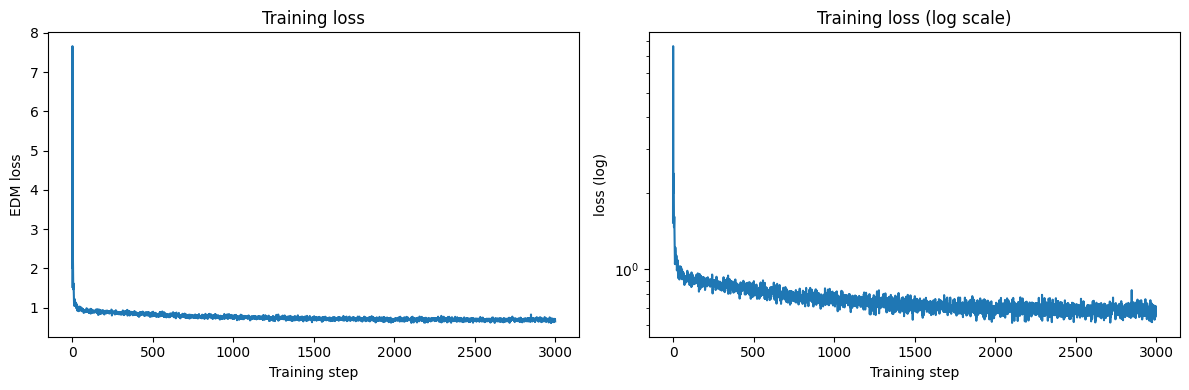

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(loss_traj)
axes[0].set_xlabel('Training step'); axes[0].set_ylabel('EDM loss'); axes[0].set_title('Training loss')
axes[1].semilogy(loss_traj)
axes[1].set_xlabel('Training step'); axes[1].set_ylabel('loss (log)'); axes[1].set_title('Training loss (log scale)')
plt.tight_layout()
plt.show()

## Sampling

In [29]:
n_samples = 2000
num_steps = 50

model_precd.eval()
latents = torch.randn(n_samples, ndim, device=device)

x_final, x_traj, x0hat_traj, t_steps = edm_sampler(
    model_precd, latents,
    num_steps=num_steps, sigma_min=0.002, sigma_max=80, rho=7,
    return_traj=True,
)
x_final_np = x_final.cpu().numpy()
x_traj_np  = x_traj.cpu().numpy()   # [T, N, 2]
print(f'Trajectory shape: {x_traj_np.shape}')

/var/folders/zc/krgdt7x11zvc_h0tv7k3mfdh0000gq/T/ipykernel_36226/3935080856.py:12: UserWarning: Use of index_put_ on expanded tensors is deprecated. Please clone() the tensor before performing this operation. This also applies to advanced indexing e.g. tensor[indices] = tensor (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1695391829313/work/aten/src/ATen/native/TensorAdvancedIndexing.cpp:711.)
  sigma[sigma == 0] = self.sigma_min


Trajectory shape: (51, 2000, 2)


## Visualization

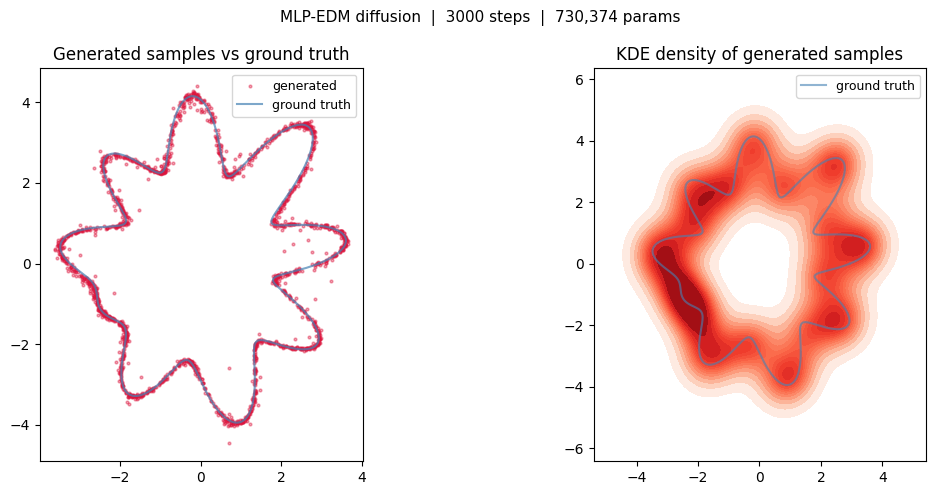

In [30]:
# Scatter: generated vs ground truth + KDE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(x_final_np[:, 0], x_final_np[:, 1], s=4, alpha=0.4, color='crimson', label='generated')
axes[0].plot(pnts_tsr[:, 0].numpy(), pnts_tsr[:, 1].numpy(), lw=1.5, alpha=0.7, color='steelblue', label='ground truth')
axes[0].set_aspect('equal'); axes[0].legend(fontsize=9)
axes[0].set_title('Generated samples vs ground truth')

sns.kdeplot(x=x_final_np[:, 0], y=x_final_np[:, 1], ax=axes[1], fill=True, cmap='Reds', levels=15)
axes[1].plot(pnts_tsr[:, 0].numpy(), pnts_tsr[:, 1].numpy(), lw=1.5, alpha=0.6, color='steelblue', label='ground truth')
axes[1].set_aspect('equal'); axes[1].legend(fontsize=9)
axes[1].set_title('KDE density of generated samples')

plt.suptitle(f'MLP-EDM diffusion  |  {nsteps} steps  |  {n_params:,} params', fontsize=11)
plt.tight_layout()
plt.show()

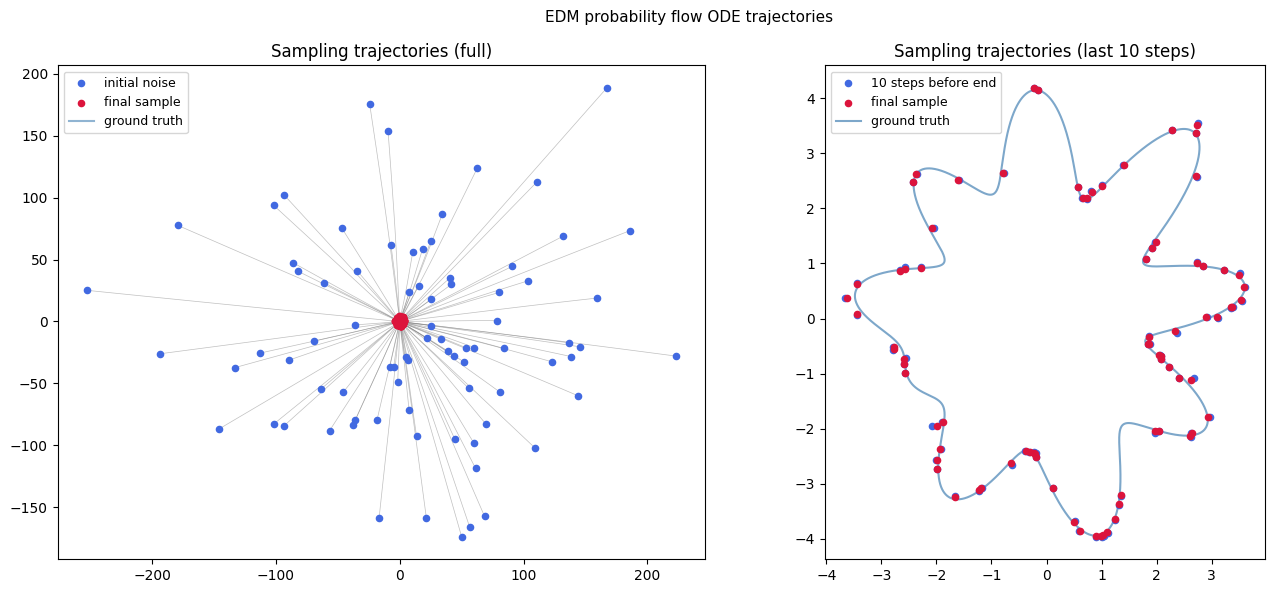

In [31]:
# Sampling trajectories
n_show = 80
idx = np.random.choice(n_samples, n_show, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(x_traj_np[0, idx, 0],  x_traj_np[0, idx, 1],  s=20, color='royalblue', zorder=3, label='initial noise')
ax.scatter(x_traj_np[-1, idx, 0], x_traj_np[-1, idx, 1], s=20, color='crimson',   zorder=3, label='final sample')
for i in idx:
    ax.plot(x_traj_np[:, i, 0], x_traj_np[:, i, 1], lw=0.5, alpha=0.5, color='gray')
ax.plot(pnts_tsr[:, 0].numpy(), pnts_tsr[:, 1].numpy(), lw=1.5, alpha=0.6, color='steelblue', label='ground truth')
ax.set_aspect('equal'); ax.legend(fontsize=9); ax.set_title('Sampling trajectories (full)')

ax = axes[1]
ax.scatter(x_traj_np[-10, idx, 0], x_traj_np[-10, idx, 1], s=20, color='royalblue', zorder=3, label='10 steps before end')
ax.scatter(x_traj_np[-1, idx, 0],  x_traj_np[-1, idx, 1],  s=20, color='crimson',   zorder=3, label='final sample')
for i in idx:
    ax.plot(x_traj_np[-10:, i, 0], x_traj_np[-10:, i, 1], lw=0.7, alpha=0.6, color='gray')
ax.plot(pnts_tsr[:, 0].numpy(), pnts_tsr[:, 1].numpy(), lw=1.5, alpha=0.7, color='steelblue', label='ground truth')
ax.set_aspect('equal'); ax.legend(fontsize=9); ax.set_title('Sampling trajectories (last 10 steps)')

plt.suptitle('EDM probability flow ODE trajectories', fontsize=11)
plt.tight_layout()
plt.show()

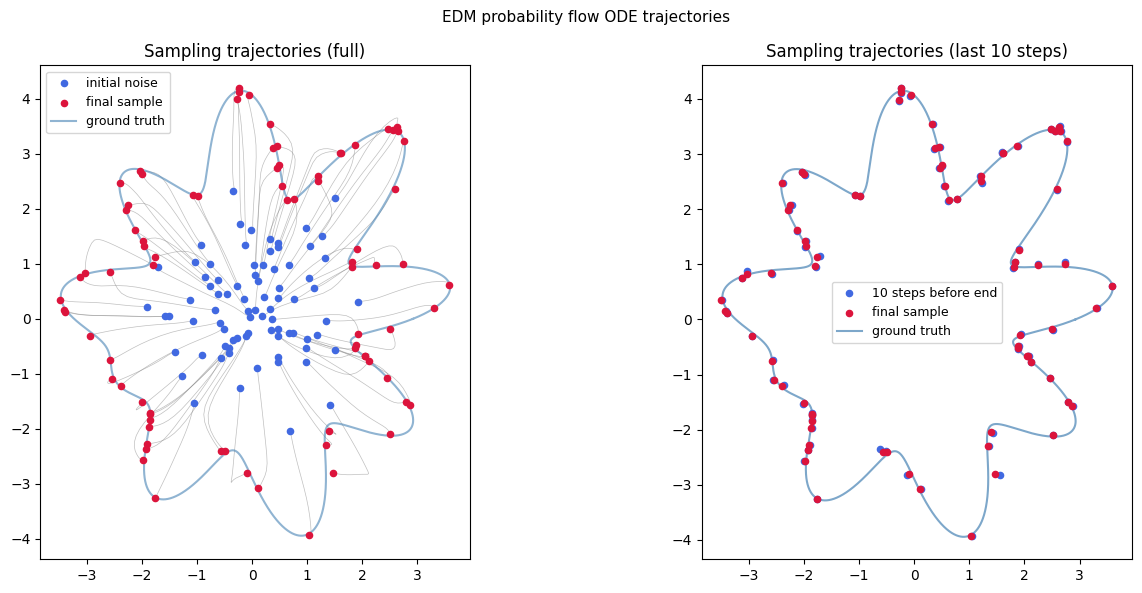

In [33]:
# Sampling trajectories
n_show = 80
idx = np.random.choice(n_samples, n_show, replace=False)
scaling = (t_steps ** 2 + 1).sqrt().cpu().numpy()
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(x_traj_np[0, idx, 0] / scaling[0],  x_traj_np[0, idx, 1] / scaling[0],  s=20, color='royalblue', zorder=3, label='initial noise')
ax.scatter(x_traj_np[-1, idx, 0] / scaling[-1], x_traj_np[-1, idx, 1] / scaling[-1], s=20, color='crimson',   zorder=3, label='final sample')
for i in idx:
    ax.plot(x_traj_np[:, i, 0] / scaling, x_traj_np[:, i, 1] / scaling, lw=0.5, alpha=0.5, color='gray')
ax.plot(pnts_tsr[:, 0].numpy(), pnts_tsr[:, 1].numpy(), lw=1.5, alpha=0.6, color='steelblue', label='ground truth')
ax.set_aspect('equal'); ax.legend(fontsize=9); ax.set_title('Sampling trajectories (full)')

ax = axes[1]
ax.scatter(x_traj_np[-10, idx, 0], x_traj_np[-10, idx, 1], s=20, color='royalblue', zorder=3, label='10 steps before end')
ax.scatter(x_traj_np[-1, idx, 0],  x_traj_np[-1, idx, 1],  s=20, color='crimson',   zorder=3, label='final sample')
for i in idx:
    ax.plot(x_traj_np[-10:, i, 0], x_traj_np[-10:, i, 1], lw=0.7, alpha=0.6, color='gray')
ax.plot(pnts_tsr[:, 0].numpy(), pnts_tsr[:, 1].numpy(), lw=1.5, alpha=0.7, color='steelblue', label='ground truth')
ax.set_aspect('equal'); ax.legend(fontsize=9); ax.set_title('Sampling trajectories (last 10 steps)')

plt.suptitle('EDM probability flow ODE trajectories', fontsize=11)
plt.tight_layout()
plt.show()

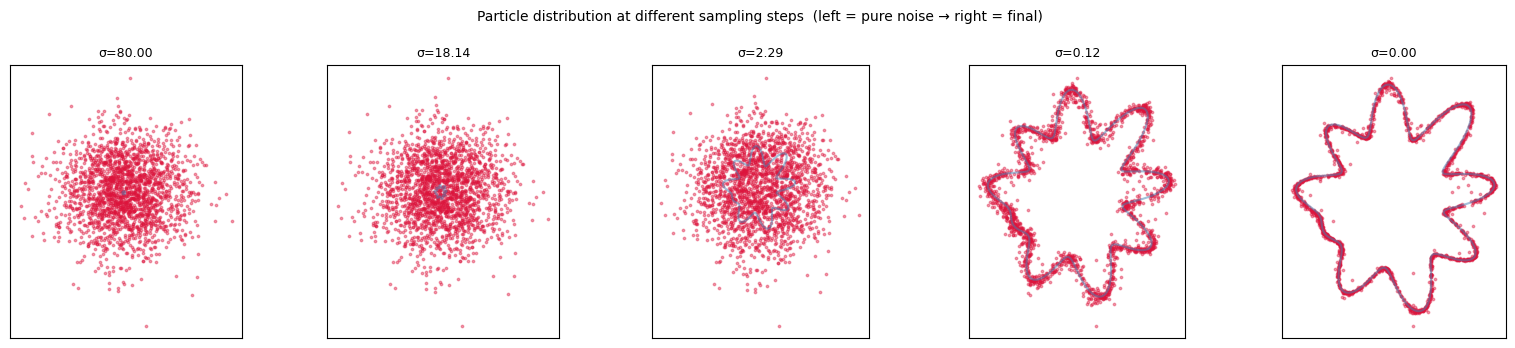

In [34]:
# Snapshots at different diffusion timesteps
T = x_traj_np.shape[0]
snap_indices = [0, T // 4, T // 2, 3 * T // 4, T - 1]
snap_labels  = [f'σ={t_steps[min(i, len(t_steps)-1)].item():.2f}' for i in snap_indices]

fig, axes = plt.subplots(1, len(snap_indices), figsize=(16, 3.5))
for ax, si, label in zip(axes, snap_indices, snap_labels):
    pts = x_traj_np[si]
    ax.scatter(pts[:, 0], pts[:, 1], s=3, alpha=0.4, color='crimson')
    ax.plot(pnts_tsr[:, 0].numpy(), pnts_tsr[:, 1].numpy(), lw=1.5, alpha=0.5, color='steelblue')
    ax.set_aspect('equal'); ax.set_title(label, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Particle distribution at different sampling steps  (left = pure noise → right = final)', fontsize=10)
plt.tight_layout()
plt.show()